# Testing trajectories to make realistic simulations

In [2]:
import matplotlib.pyplot as plt
import numpy as np



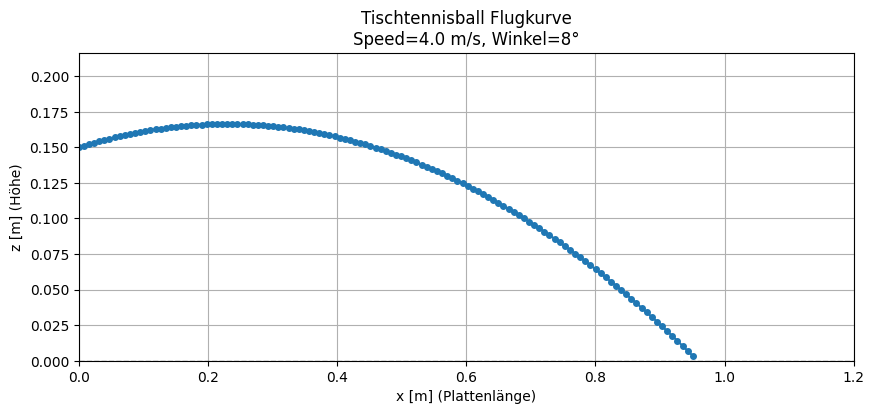

In [7]:
# Parameter für den Tisch und die Simulation
g = 9.81            # Erdbeschleunigung [m/s^2]
dt = 0.002          # Zeitschritt
timesteps = 2000
ausschnitt = 1.2    # Bildausschnitt: halbe Tischtennisplatte (~1.37 m) + etwas mehr

# --- NEUE Steuerparameter ---
speed = 4.0          # Anfangsgeschwindigkeit [m/s]
angle_deg = 8        # Winkel in Grad (0 = horizontal, positiv = nach oben)
# ----------------------------

# Berechnung der Geschwindigkeitskomponenten
angle_rad = np.deg2rad(angle_deg)
vx = speed * np.cos(angle_rad)
vz = speed * np.sin(angle_rad)

# Startbedingungen
pos = np.array([0.0, 0.0, 0.15])   # Start leicht über Platte (15 cm)
velocity = np.array([vx, 0.0, vz])

# Arrays speichern
positions = [pos.copy()]

for t in range(timesteps):
    pos = pos + velocity * dt
    velocity[2] -= g * dt   # Gravitation auf z
    
    if pos[2] <= 0:   # Ball erreicht Platte
        break
    
    positions.append(pos.copy())

positions = np.array(positions)

# Nur den Bildausschnitt zeigen (halbe Platte + bisschen mehr)
mask = positions[:,0] <= ausschnitt
positions_cut = positions[mask]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(positions_cut[:,0], positions_cut[:,2], 'o-', markersize=4)

plt.title(f"Tischtennisball Flugkurve\nSpeed={speed} m/s, Winkel={angle_deg}°")
plt.xlabel("x [m] (Plattenlänge)")
plt.ylabel("z [m] (Höhe)")
plt.grid(True)

plt.xlim(0, ausschnitt)
plt.ylim(0, positions_cut[:,2].max() + 0.05)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)


plt.show()